Creating sample data so the code runs without a file...

--- Average Stats Per Cluster ---
          Income    Age  Recency
Cluster                         
0        92500.0  45.25     18.0
1        52500.0  37.50     12.5
2        22500.0  27.00     85.0


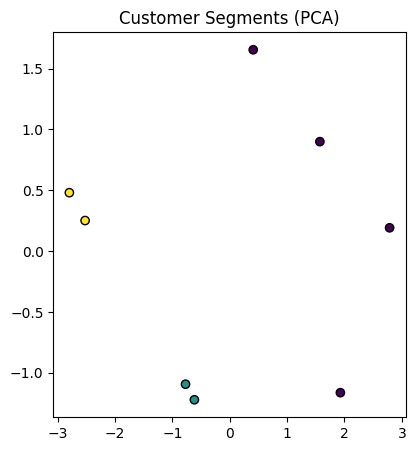

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import tkinter as tk
from tkinter import filedialog

try:
   
    print("Creating sample data so the code runs without a file...")
    data = {
        'Income': [50000, 60000, 120000, 20000, 80000, 55000, 110000, 25000],
        'Year_Birth': [1985, 1990, 1975, 1995, 1980, 1988, 1970, 1999],
        'Recency': [10, 45, 5, 80, 20, 15, 2, 90],
        'Marital_Status': ['Single', 'Married', 'Divorced', 'Single', 'Married', 'Single', 'Married', 'Single']
    }
    df = pd.DataFrame(data)


except Exception as e:
    print(f"Make sure you have a file! Error: {e}")


df['Age'] = 2024 - df['Year_Birth']


df['Income'] = df['Income'].fillna(df['Income'].median())

df_prepared = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)


features = ['Income', 'Recency', 'Age'] + [col for col in df_prepared.columns if 'Marital_Status' in col]
X = df_prepared[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', edgecolors='k')
plt.title('Customer Segments (PCA)')


print("\n--- Average Stats Per Cluster ---")
print(df.groupby('Cluster')[['Income', 'Age', 'Recency']].mean())

plt.show()
